In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
train_dir = '/content/drive/MyDrive/Deepfake_Project/Deepfake_Project/Dataset_Split/extracted/train'
val_dir = '/content/drive/MyDrive/Deepfake_Project/Deepfake_Project/Dataset_Split/extracted/val'
test_dir = '/content/drive/MyDrive/Deepfake_Project/Deepfake_Project/Dataset_Split/extracted/test'

In [19]:
img_size = 180
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [20]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 69094 images belonging to 2 classes.
Found 12194 images belonging to 2 classes.
Found 14346 images belonging to 2 classes.


In [21]:
base_model = DenseNet121(input_shape=(img_size, img_size, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

In [22]:
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 186, 186,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 90, 90,    │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 90, 90,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 90, 90,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 92, 92,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 45, 45,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 45, 45,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 45, 45,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 45, 45,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 45, 45,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 45, 45,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 45, 45,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 45, 45,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 45, 45,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 45, 45,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 45, 45,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6),
    ModelCheckpoint('DenseNet121_model.h5', monitor='val_loss', save_best_only=True)
]

In [24]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,           # Limit steps per epoch for speed
    validation_steps=20,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8384 - loss: 0.4846 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1421s 14s/step - accuracy: 0.8383 - loss: 0.4847 - val_accuracy: 0.8281 - val_loss: 0.4757 - learning_rate: 0.0010
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1330s 13s/step - accuracy: 0.8221 - loss: 0.4794 - val_accuracy: 0.8250 - val_loss: 0.4768 - learning_rate: 0.0010
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8465 - loss: 0.4354 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1266s 13s/step - accuracy: 0.8465 - loss: 0.4356 - val_accuracy: 0.8281 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8200 - loss: 0.4731 

100/100 ━━━━━━━━━━━━━━━━━━━━ 1237s 12s/step - accuracy: 0.8200 - loss: 0.4731 - val_accuracy: 0.8406 - val_loss: 0.4207 - learning_rate: 0.0010
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1090s 11s/step - accuracy: 0.8231 - loss: 0.4673 - val_accuracy: 0.8125 - val_loss: 0.4732 - learning_rate: 0.0010
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8122 - loss: 0.4883

100/100 ━━━━━━━━━━━━━━━━━━━━ 980s 10s/step - accuracy: 0.8123 - loss: 0.4882 - val_accuracy: 0.8469 - val_loss: 0.4098 - learning_rate: 0.0010
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 886s 9s/step - accuracy: 0.8244 - loss: 0.4406 - val_accuracy: 0.8250 - val_loss: 0.4454 - learning_rate: 0.0010
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 972s 10s/step - accuracy: 0.8165 - loss: 0.4914 - val_accuracy: 0.8062 - val_loss: 0.4848 - learning_rate: 0.0010
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 912s 9s/step - accuracy: 0.8211 - loss: 0.4610 - val_accuracy: 0.8281 - val_loss: 0.4427 - learning_rate: 0.0010
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 875s 9s/step - accuracy: 0.8406 - loss: 0.4133 - val_accuracy: 0.8031 - val_loss: 0.4799 - learning_rate: 2.0000e-04
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 901s 9s/step - accuracy: 0.8408 - loss: 0.4149 - val_accuracy: 0.8000 - val_loss: 0.4541 - learning_rate: 2.0000e-04


In [25]:
from google.colab import files
files.download('DenseNet121_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

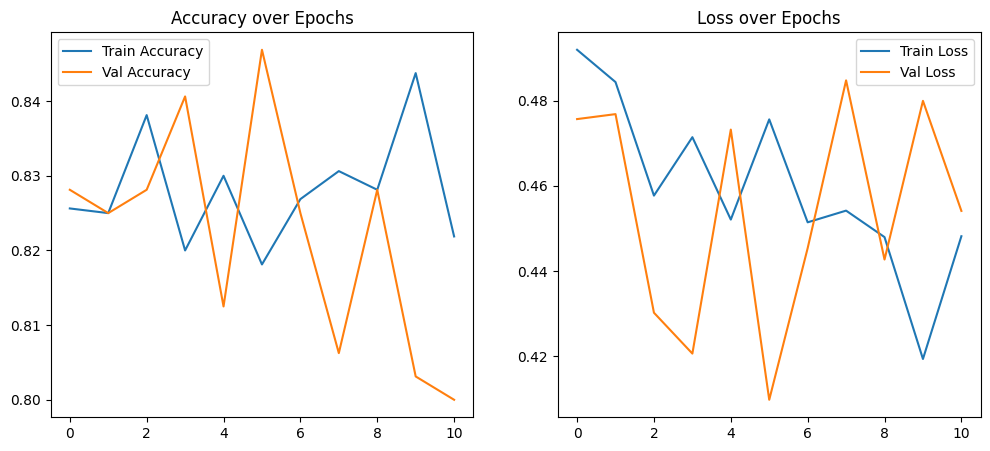

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [50]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

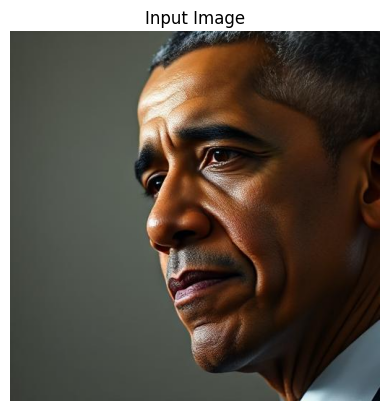

In [51]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(img_path):
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

image_path = 'fake_4.jpeg'
show_image(image_path)

In [52]:
# Load your trained model
model = load_model('DenseNet121_model.h5')

def predict_deepfake(img_path, model, img_size=180, thresh=0.005):

    img = image.load_img(img_path, target_size=(img_size, img_size))
    x = image.img_to_array(img)
    x = np.expand_dims(x, 0)
    x = preprocess_input(x)

    prob = model.predict(x)[0][0]
    label = 'Fake' if prob > thresh else 'Real'

    print(f"Image: {img_path}")
    print(f"→ Prediction = {label}")

predict_deepfake(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Image: fake_4.jpeg
→ Prediction = Fake


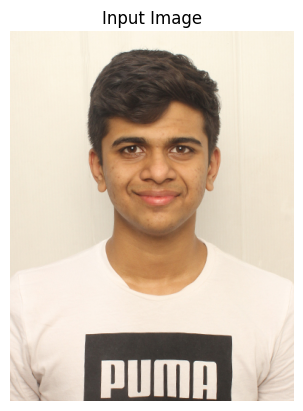

In [53]:
image_path = 'Aditya_Photo.jpg'
show_image(image_path)

In [54]:
predict_deepfake(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
Image: Aditya_Photo.jpg
→ Prediction = Real
